# Deterministic coarsening round-trip visual checks

This notebook repeats the central operations from the automated scripts in this directory, using the **same seed constants and graph constructors**:

- seeded simulation reproducibility;
- one Star coarsening and reversal;
- one edge-BPE coarsening and reversal;
- one named-component coarsening and reversal;
- Star → BPE with reverse-stage decoding;
- BPE → Star with reverse-stage decoding.

The assertions are intentionally the same kind used by the scripts. The additional plots make it possible to inspect the contractions by eye.

## 0. Imports and shared deterministic fixtures

In [1]:
from pathlib import Path
import sys
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "tree_coarsening").is_dir():
    for candidate in PROJECT_ROOT.parents:
        if (candidate / "tree_coarsening").is_dir():
            PROJECT_ROOT = candidate
            break
sys.path.insert(0, str(PROJECT_ROOT))

from tree_coarsening import EdgeBPECoarsener, NamedVertexCoarsener, StarCoarsener
from tests.roundtrip_suite.common import (
    BPE_SEED,
    NAMED_SEED,
    PIPELINE_SEED,
    STAR_SEED,
    VISUAL_LAYOUT_SEED,
    assert_encoded_invariants,
    assert_encoded_stage_equal,
    assert_raw_roundtrip,
    assert_reproducible,
    make_bpe_graphs,
    make_bpe_then_star_graphs,
    make_named_graph,
    make_star_graphs,
    stage_summary,
    token_text,
)

print("Project root:", PROJECT_ROOT)
print(
    "Seeds:",
    dict(star=STAR_SEED, bpe=BPE_SEED, named=NAMED_SEED, pipeline=PIPELINE_SEED),
)

Project root: /mnt/data/tree_coarsening_0_10_test_suite
Seeds: {'star': 17041, 'bpe': 29117, 'named': 31337, 'pipeline': 44021}


## 1. Small deterministic tree visualizer

In [2]:
def tree_layout(graph):
    """Deterministic hierarchy: depth vertically, leaves ordered horizontally."""

    roots = [node for node, degree in graph.in_degree() if degree == 0]
    positions = {}
    next_x = 0.0

    def assign(node, depth):
        nonlocal next_x
        children = sorted(
            graph.successors(node),
            key=lambda child: (
                float(graph.nodes[child].get("time", 0.0)),
                repr(graph.nodes[child].get("label")),
                repr(child),
            ),
        )
        if not children:
            positions[node] = (next_x, -depth)
            next_x += 1.0
            return
        for child in children:
            assign(child, depth + 1)
        positions[node] = (
            sum(positions[child][0] for child in children) / len(children),
            -depth,
        )

    for root in sorted(roots, key=repr):
        assign(root, 0)
        next_x += 1.0
    return positions


def stage_label(data):
    label = token_text(data["label"])
    size = int(data.get("size", 1))
    return label if size == 1 else f"{label}\nsize={size}"


def draw_tree(ax, graph, title):
    pos = tree_layout(graph)
    display_labels = {node: stage_label(data) for node, data in graph.nodes(data=True)}
    categories = [display_labels[node].split("\n")[0] for node in graph]
    unique = sorted(set(categories))
    palette = plt.get_cmap("tab20")
    color_for = {value: palette(i % 20) for i, value in enumerate(unique)}
    colors = [color_for[value] for value in categories]
    sizes = [80 + 45 * (int(graph.nodes[node].get("size", 1)) ** 0.5) for node in graph]

    nx.draw_networkx_edges(
        graph,
        pos,
        ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=10,
        width=0.8,
        edge_color="0.55",
    )
    nx.draw_networkx_nodes(
        graph,
        pos,
        ax=ax,
        node_color=colors,
        node_size=sizes,
        linewidths=0.6,
        edgecolors="0.2",
    )
    if graph.number_of_nodes() <= 45:
        nx.draw_networkx_labels(graph, pos, labels=display_labels, font_size=6, ax=ax)
    ax.set_title(f"{title}\n{graph.number_of_nodes()} nodes / {graph.number_of_edges()} edges")
    ax.set_axis_off()


def draw_stages(stages, *, figsize_per_stage=5.2):
    fig, axes = plt.subplots(
        1,
        len(stages),
        figsize=(figsize_per_stage * len(stages), 6),
        squeeze=False,
    )
    for ax, (title, graph) in zip(axes[0], stages):
        draw_tree(ax, graph, title)
    plt.tight_layout()
    plt.show()

## 2. Simulation reproducibility

Star corpus sizes: [9, 25, 46, 9]
BPE corpus sizes: [36, 36, 36]
Named graph size: 16


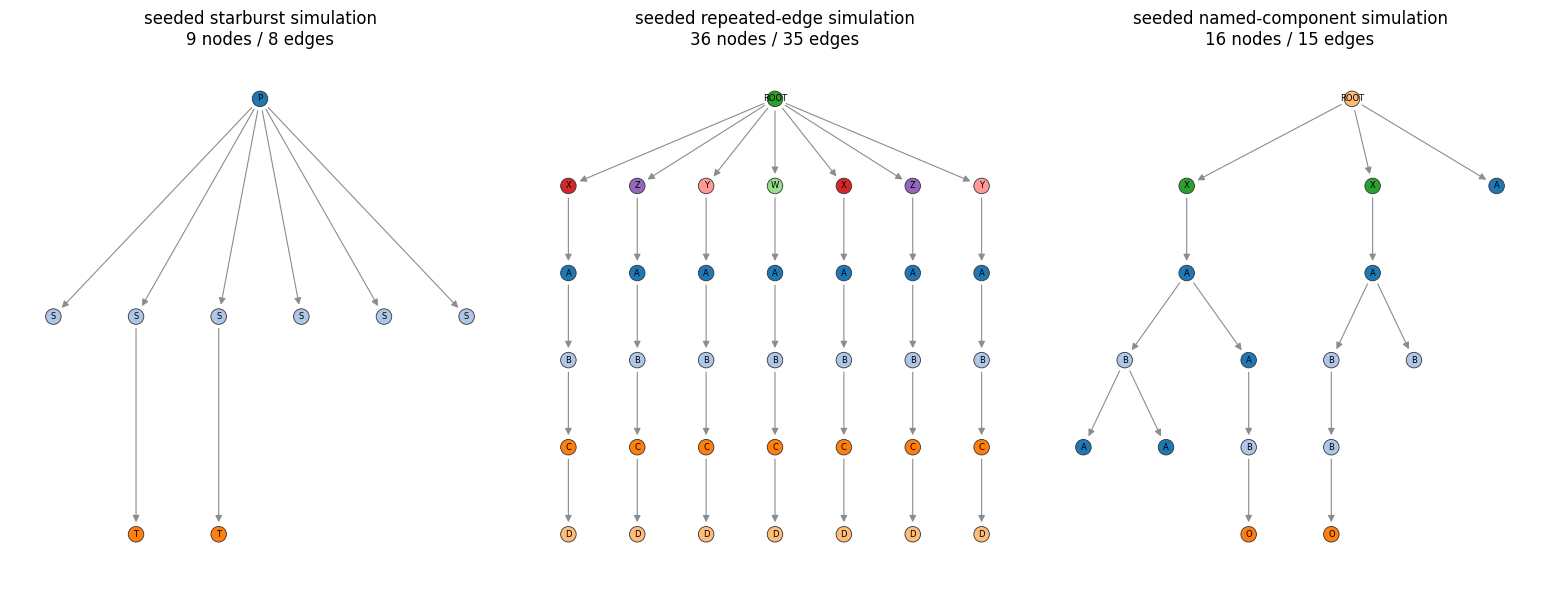

In [3]:
star_a = make_star_graphs()
star_b = make_star_graphs()
bpe_a = make_bpe_graphs()
bpe_b = make_bpe_graphs()
named_a = make_named_graph()
named_b = make_named_graph()

assert_reproducible(star_a, star_b)
assert_reproducible(bpe_a, bpe_b)
assert named_a.number_of_nodes() == named_b.number_of_nodes()
assert named_a.number_of_edges() == named_b.number_of_edges()

print("Star corpus sizes:", [graph.number_of_nodes() for graph in star_a])
print("BPE corpus sizes:", [graph.number_of_nodes() for graph in bpe_a])
print("Named graph size:", named_a.number_of_nodes())
draw_stages([
    ("seeded starburst simulation", star_a[0]),
    ("seeded repeated-edge simulation", bpe_a[0]),
    ("seeded named-component simulation", named_a),
])

## 3. Single-stage Star round trip

Learned star tokens: 3


,stage,raw_nodes,encoded_nodes,compression_ratio,encoded_edges,represented_size
0,star,9,4,0.444444,3,9


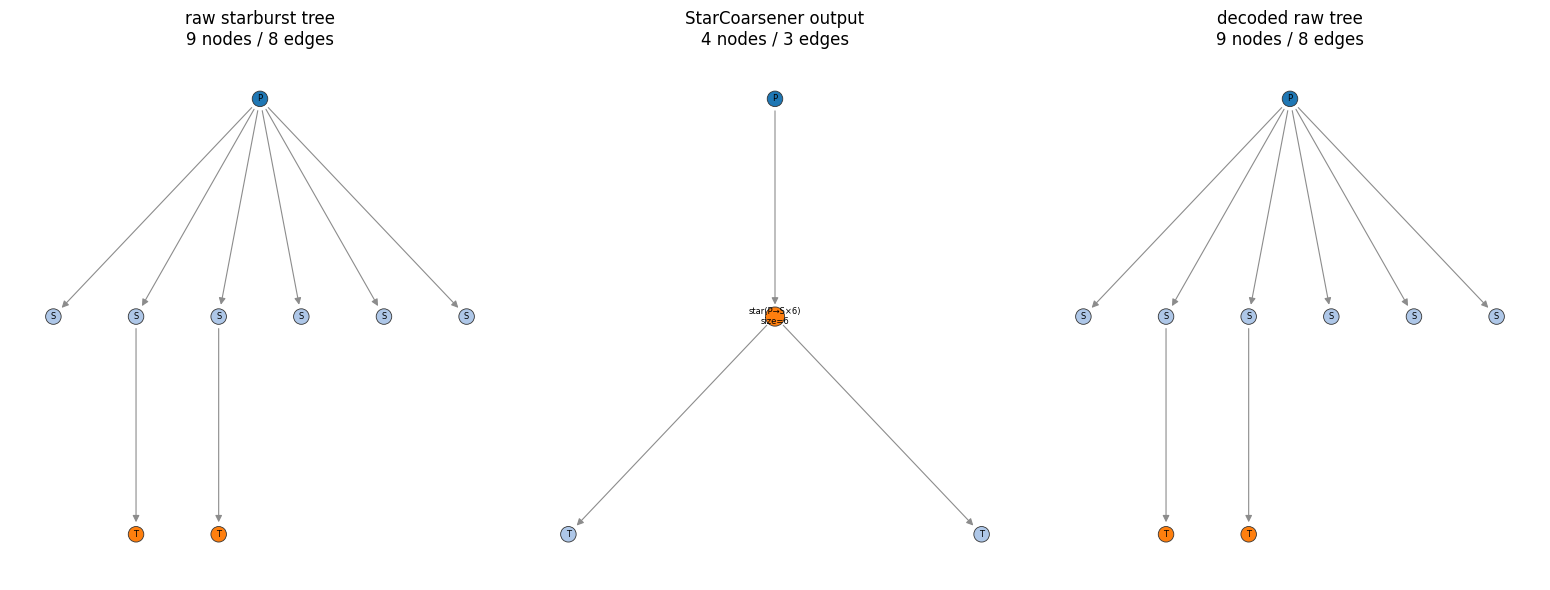

In [4]:
star_graphs = make_star_graphs()
star_model = StarCoarsener(d=4, m=2, contract_d=3).fit(star_graphs)
star_encoded = star_model.transform(star_graphs[0])
star_decoded = star_model.inverse_transform(star_encoded)

assert_encoded_invariants(star_graphs[0], star_encoded)
assert_raw_roundtrip(star_graphs[0], star_decoded)
print("Learned star tokens:", len(star_model.encoder_.vocab.entries))
display(pd.DataFrame([stage_summary("star", star_graphs[0], star_encoded)]))
draw_stages([
    ("raw starburst tree", star_graphs[0]),
    ("StarCoarsener output", star_encoded),
    ("decoded raw tree", star_decoded),
])

## 4. Single-stage edge-BPE round trip

BPE history:


,rank,token,parent_label,child_label,parent_token,child_token,count,count_semantics,actual_events
0,0,"(edge_bpe, 0)",C,D,C,D,21,raw_matching_edges,21
1,1,"(edge_bpe, 1)",B,"(edge_bpe, 0)",B,"(edge_bpe, 0)",21,raw_matching_edges,21
2,2,"(edge_bpe, 2)",A,"(edge_bpe, 1)",A,"(edge_bpe, 1)",21,raw_matching_edges,21
3,3,"(edge_bpe, 3)",Z,"(edge_bpe, 2)",Z,"(edge_bpe, 2)",6,raw_matching_edges,6


,stage,raw_nodes,encoded_nodes,compression_ratio,encoded_edges,represented_size
0,edge_bpe,36,13,0.361111,12,36


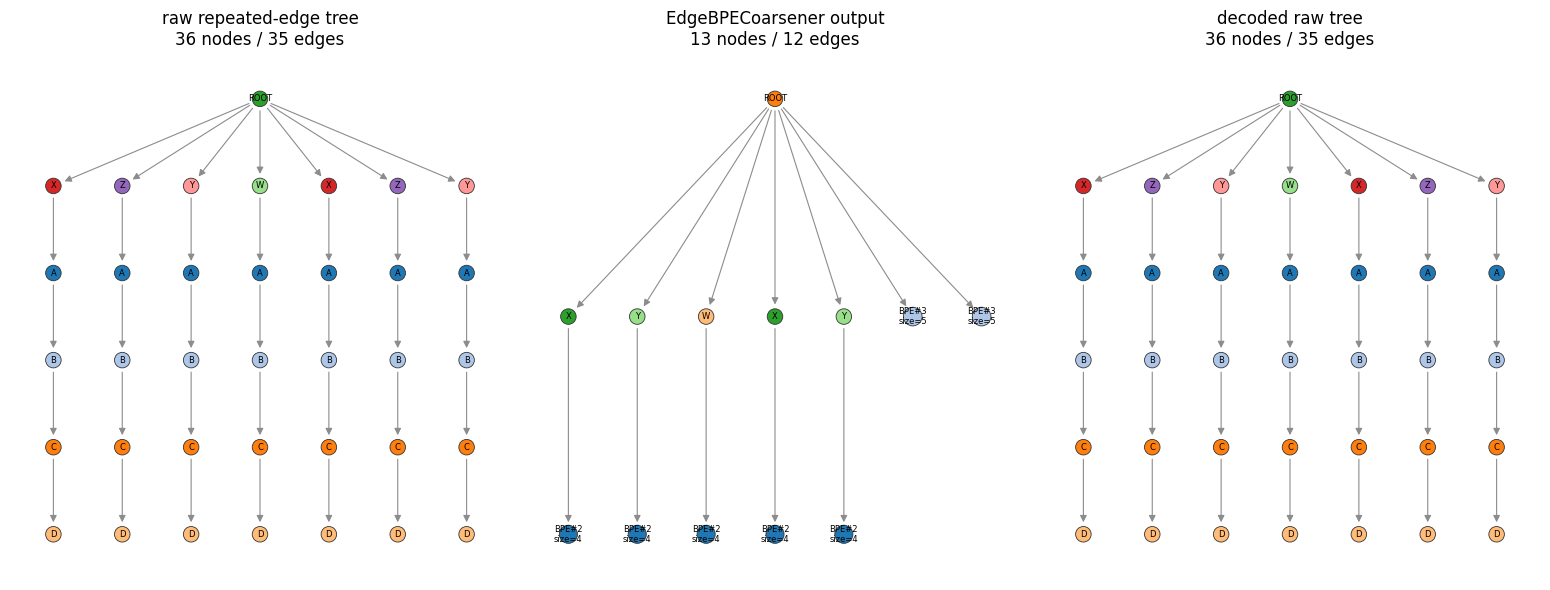

In [5]:
bpe_graphs = make_bpe_graphs()
bpe_model = EdgeBPECoarsener(num_merges=4, min_pair_count=4).fit(bpe_graphs)
bpe_encoded = bpe_model.transform(bpe_graphs[0])
bpe_decoded = bpe_model.inverse_transform(bpe_encoded)

assert_encoded_invariants(bpe_graphs[0], bpe_encoded)
assert_raw_roundtrip(bpe_graphs[0], bpe_decoded)
print("BPE history:")
display(pd.DataFrame(bpe_model.history_))
display(pd.DataFrame([stage_summary("edge_bpe", bpe_graphs[0], bpe_encoded)]))
draw_stages([
    ("raw repeated-edge tree", bpe_graphs[0]),
    ("EdgeBPECoarsener output", bpe_encoded),
    ("decoded raw tree", bpe_decoded),
])

## 5. Single-stage named-component round trip

,stage,raw_nodes,encoded_nodes,compression_ratio,encoded_edges,represented_size
0,named_components,16,8,0.5,7,16


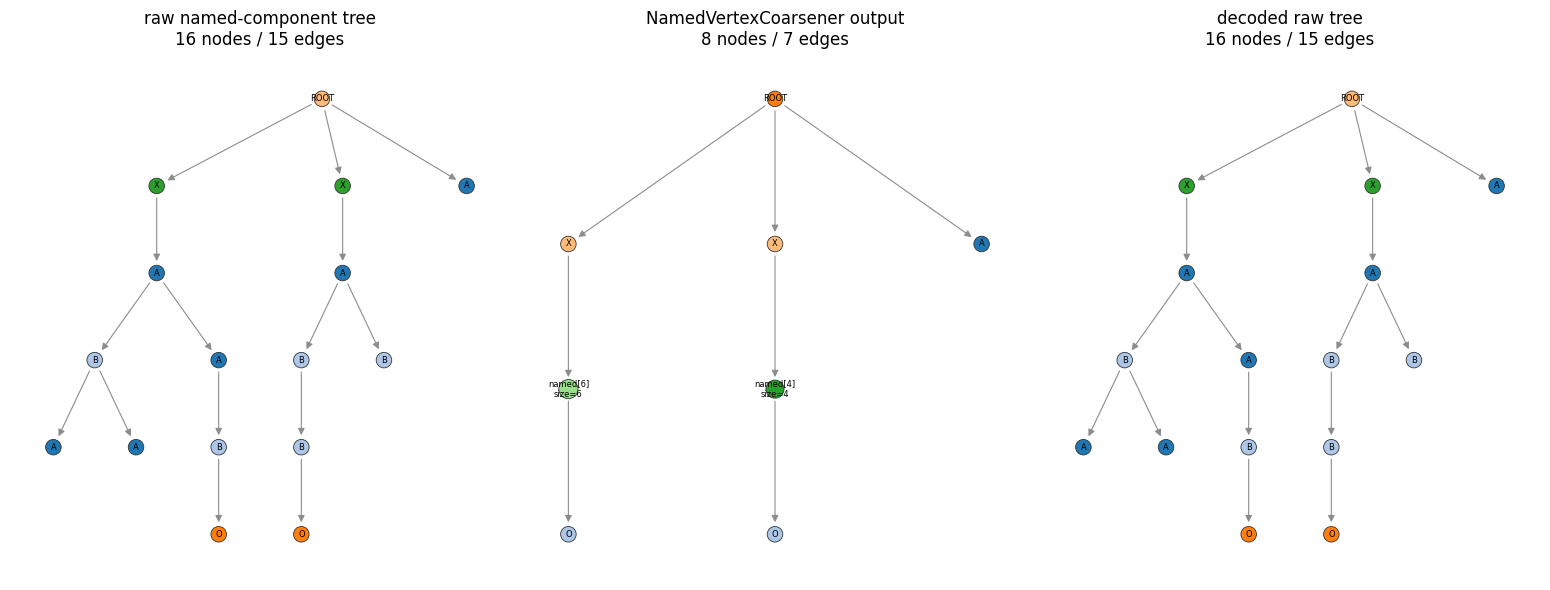

In [6]:
named_graph = make_named_graph()
named_model = NamedVertexCoarsener(
    labels={"A", "B"},
    component_policy="all",
).fit(named_graph)
named_encoded = named_model.transform(named_graph)
named_decoded = named_model.inverse_transform(named_encoded)

assert_encoded_invariants(named_graph, named_encoded)
assert_raw_roundtrip(named_graph, named_decoded)
display(pd.DataFrame([stage_summary("named_components", named_graph, named_encoded)]))
draw_stages([
    ("raw named-component tree", named_graph),
    ("NamedVertexCoarsener output", named_encoded),
    ("decoded raw tree", named_decoded),
])

## 6. Star → BPE → reverse BPE → reverse Star

,stage,raw_nodes,encoded_nodes,compression_ratio,encoded_edges,represented_size
0,star,9,4,0.444444,3,9
1,star_then_bpe,9,1,0.111111,0,9


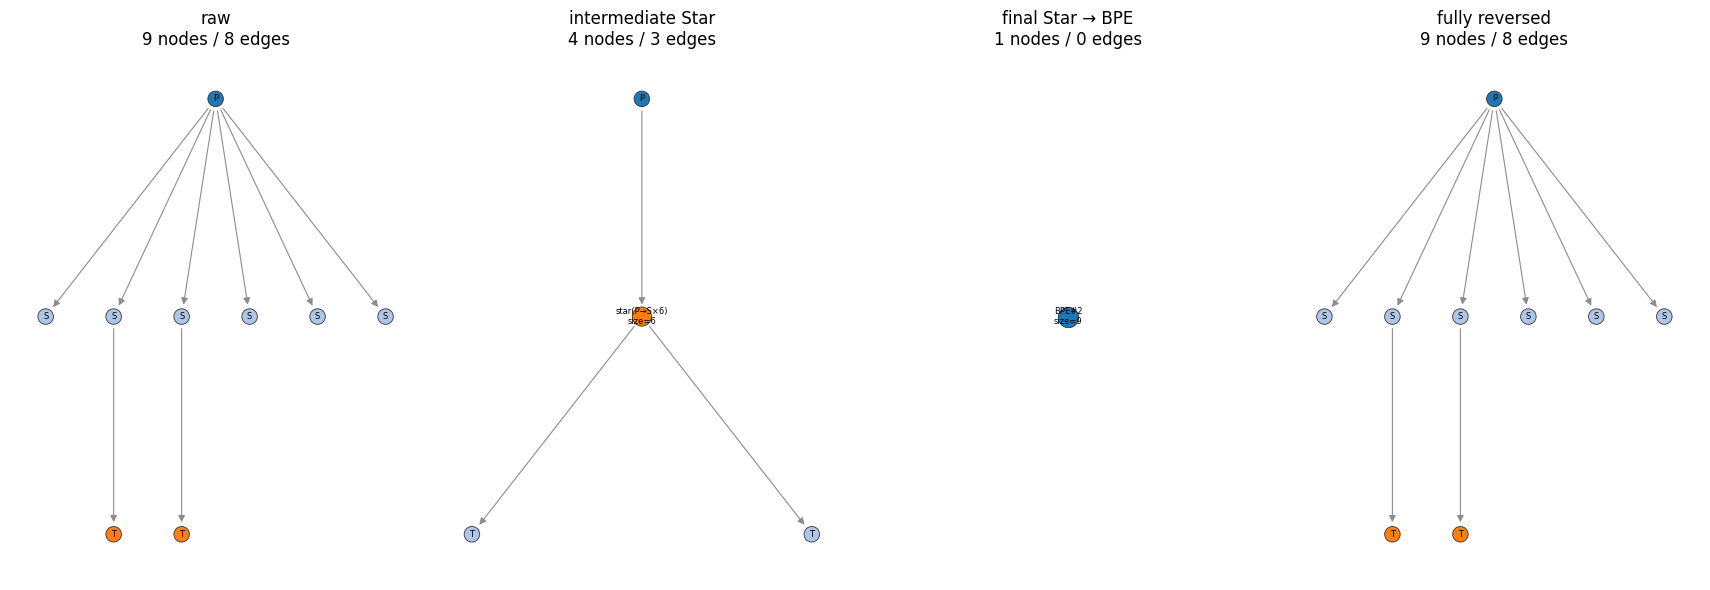

In [7]:
raw_pipeline = make_star_graphs()
star_stage_model = StarCoarsener(d=4, m=2, contract_d=3).fit(raw_pipeline)
star_stage = star_stage_model.transform(raw_pipeline)

bpe_stage_model = EdgeBPECoarsener(num_merges=10, min_pair_count=2).fit(star_stage)
final_stage = bpe_stage_model.transform(star_stage)

intermediate_recovered = bpe_stage_model.inverse_transform(final_stage[0])
raw_recovered = star_stage_model.inverse_transform(intermediate_recovered)

assert_encoded_invariants(raw_pipeline[0], star_stage[0])
assert_encoded_invariants(raw_pipeline[0], final_stage[0])
assert_encoded_stage_equal(star_stage[0], intermediate_recovered)
assert_raw_roundtrip(raw_pipeline[0], raw_recovered)

display(pd.DataFrame([
    stage_summary("star", raw_pipeline[0], star_stage[0]),
    stage_summary("star_then_bpe", raw_pipeline[0], final_stage[0]),
]))
draw_stages([
    ("raw", raw_pipeline[0]),
    ("intermediate Star", star_stage[0]),
    ("final Star → BPE", final_stage[0]),
    ("fully reversed", raw_recovered),
], figsize_per_stage=4.3)

## 7. BPE → Star → reverse Star → reverse BPE

,stage,raw_nodes,encoded_nodes,compression_ratio,encoded_edges,represented_size
0,bpe,13,12,0.923077,11,13
1,bpe_then_star,13,8,0.615385,7,13


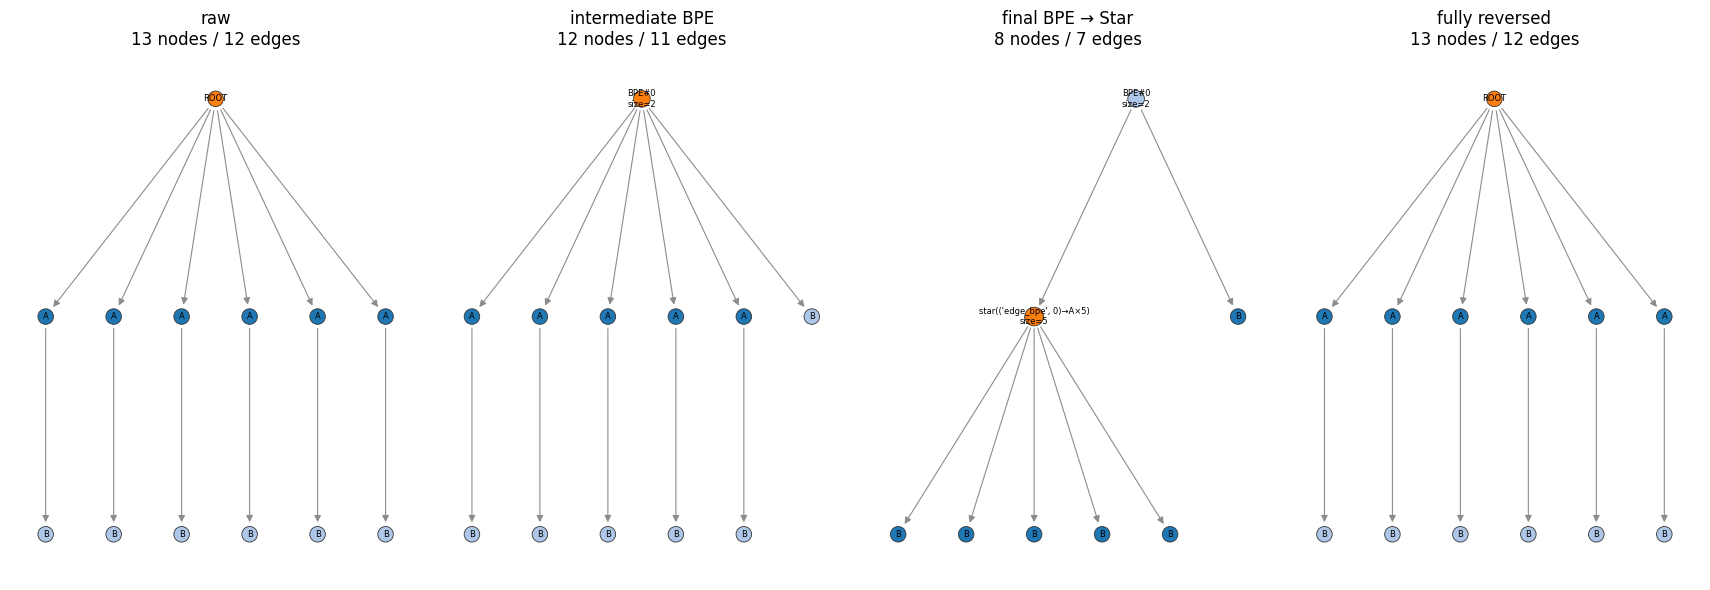

In [8]:
reverse_raw = make_bpe_then_star_graphs()
first_bpe = EdgeBPECoarsener(num_merges=1, min_pair_count=2).fit(reverse_raw)
first_stage = first_bpe.transform(reverse_raw)

second_star = StarCoarsener(d=4, m=1, contract_d=4).fit(first_stage)
second_stage = second_star.transform(first_stage)

first_stage_recovered = second_star.inverse_transform(second_stage[0])
reverse_raw_recovered = first_bpe.inverse_transform(first_stage_recovered)

assert_encoded_invariants(reverse_raw[0], first_stage[0])
assert_encoded_invariants(reverse_raw[0], second_stage[0])
assert_encoded_stage_equal(first_stage[0], first_stage_recovered)
assert_raw_roundtrip(reverse_raw[0], reverse_raw_recovered)

display(pd.DataFrame([
    stage_summary("bpe", reverse_raw[0], first_stage[0]),
    stage_summary("bpe_then_star", reverse_raw[0], second_stage[0]),
]))
draw_stages([
    ("raw", reverse_raw[0]),
    ("intermediate BPE", first_stage[0]),
    ("final BPE → Star", second_stage[0]),
    ("fully reversed", reverse_raw_recovered),
], figsize_per_stage=4.3)

## 8. Other reasonable automated tests

Useful additions beyond this base suite include:

- invalid-tree and malformed-schema rejection;
- missing/duplicate UID behavior;
- attachment-map boundary cases and partial decoding;
- exact `label` versus `type` behavior for multiple attachment variants;
- raw matching-edge counts versus non-overlapping `actual_events`;
- Python/Numba BPE history parity over randomized corpora;
- serialization/pickle round trips for fitted models;
- larger randomized property tests checking size, max-time, UID partition, and reverse-stage recovery;
- deterministic results after NetworkX node insertion order is permuted.
